In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
train1 = pd.read_csv("../data/multiview_pig_posture_recognition/train1.csv", converters={"bbox": ast.literal_eval})
train2 = pd.read_csv("../data/multiview_pig_posture_recognition/train2.csv", converters={"bbox": ast.literal_eval})
test = pd.read_csv("../data/multiview_pig_posture_recognition/test.csv",  converters={"bbox": ast.literal_eval})

In [3]:
train1.groupby("image_id").groups

{'pen1_orb_cam1_20250108_085204.jpg': [0, 1, 2, 3, 4, 5, 6], 'pen1_orb_cam1_20250108_085209.jpg': [7, 8, 9, 10, 11, 12, 13], 'pen1_orb_cam1_20250108_085214.jpg': [14, 15, 16, 17, 18, 19, 20], 'pen1_orb_cam1_20250108_085219.jpg': [21, 22, 23, 24, 25, 26, 27], 'pen1_orb_cam1_20250108_085224.jpg': [28, 29, 30, 31, 32, 33, 34], 'pen1_orb_cam1_20250108_085229.jpg': [35, 36, 37, 38, 39, 40, 41], 'pen1_orb_cam1_20250108_085521.jpg': [42, 43, 44, 45, 46, 47, 48], 'pen1_orb_cam1_20250108_085526.jpg': [49, 50, 51, 52, 53, 54, 55], 'pen1_orb_cam1_20250108_085531.jpg': [56, 57, 58, 59, 60, 61, 62], 'pen1_orb_cam1_20250108_085536.jpg': [63, 64, 65, 66, 67, 68, 69], 'pen1_orb_cam1_20250108_085541.jpg': [70, 71, 72, 73, 74, 75, 76], 'pen1_orb_cam1_20250108_085546.jpg': [77, 78, 79, 80, 81, 82, 83], 'pen1_orb_cam1_20250108_085551.jpg': [84, 85, 86, 87, 88, 89, 90], 'pen1_orb_cam1_20250108_085556.jpg': [91, 92, 93, 94, 95, 96, 97], 'pen1_orb_cam1_20250108_085601.jpg': [98, 99, 100, 101, 102, 103, 104],

In [4]:
len(train1.groupby("image_id").groups)

3090

In [5]:
len(train2.groupby("image_id"))

3150

In [6]:
train1

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5, 368.0, 349.0, 435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5, 428.0, 233.0, 438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0, 137.5, 342.0, 198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0, 169.0, 370.0, 263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5, 314.8, 381.5, 386.6]",3
...,...,...,...,...,...,...
22929,train_pen2_tur_cam1_20250215_095748_0004,pen2_tur_cam1_20250215_095748.jpg,1280,720,"[254.5, 160.0, 229.0, 128.0]",3
22930,train_pen2_tur_cam1_20250215_095748_0005,pen2_tur_cam1_20250215_095748.jpg,1280,720,"[98.0, 217.0, 97.0, 207.0]",3
22931,train_pen2_tur_cam1_20250215_095748_0006,pen2_tur_cam1_20250215_095748.jpg,1280,720,"[956.0, 63.5, 141.0, 398.0]",4
22932,train_pen2_tur_cam1_20250215_095748_0007,pen2_tur_cam1_20250215_095748.jpg,1280,720,"[247.0, 345.0, 149.0, 228.0]",3


In [7]:
train2

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5, 368.0, 349.0, 435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5, 428.0, 233.0, 438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0, 137.5, 342.0, 198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0, 169.0, 370.0, 263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5, 314.8, 381.5, 386.6]",3
...,...,...,...,...,...,...
23445,train_pen2_tur_cam2_20250120_082753_0004,pen2_tur_cam2_20250120_082753.jpg,2688,1520,"[1507.5, 90.5, 554.0, 387.0]",4
23446,train_pen2_tur_cam2_20250120_082753_0005,pen2_tur_cam2_20250120_082753.jpg,2688,1520,"[1508.0, 828.5, 475.0, 319.0]",3
23447,train_pen2_tur_cam2_20250120_082753_0006,pen2_tur_cam2_20250120_082753.jpg,2688,1520,"[1896.6, 856.5, 325.0, 218.0]",4
23448,train_pen2_tur_cam2_20250120_082753_0007,pen2_tur_cam2_20250120_082753.jpg,2688,1520,"[2179.5, 318.0, 151.0, 397.0]",1


<Axes: >

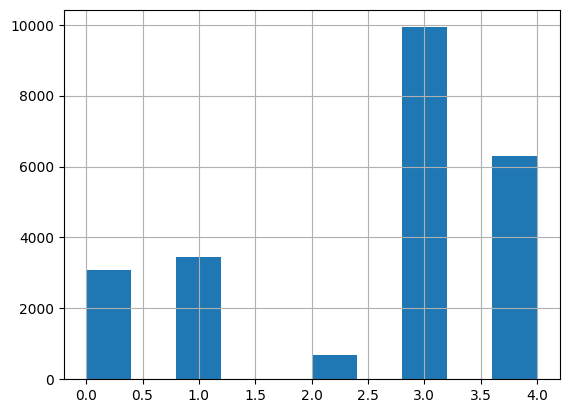

In [8]:
train2["class_id"].hist()

In [9]:
x = [value["bbox"][0]* 1280 / value["width"] for i, value in train2.iterrows()]
y = [value["bbox"][1]* 720 / value["height"] for i, value in train2.iterrows()]

(array([[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,  15.,  27.,  15.,
          14.,  17.,  16.,  24.,  27.,  39.,  47.,  61.,  36.,  24.,  17.,
          16.,  29.,  22.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   1.,   0.,  19.,  37.,  52.,  64.,  47.,
          22.,  17.,  14.,   9.,   9.,  19.,  57.,  19.,  14.,  10.,  21.,
          11.,  30.,  31.,   2.,   0.,   0.,   0.,   0.],
        [  1.,   0.,   0.,   0.,  42.,  74.,  97.,  75.,  96.,  51.,  41.,
          68.,  29.,  37.,  65.,  42.,  29.,  18.,  13.,  21.,   9.,   7.,
           2.,  25.,  55.,   4.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   3.,   4.,  42.,  56., 192., 112.,  55.,  35.,  17.,
          38.,  65., 113.,  47.,  60., 101.,  47.,  39.,  24.,  21.,  30.,
          10.,   3.,   9.,   9.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   7.,  15.,  14., 131., 194.,  31.,  25.,  26.,  29.,
          25.,  29.,  30.,  29.,  27.,  45.,  55.,  74.,  62.,  55.,  46.,
          40.,  21

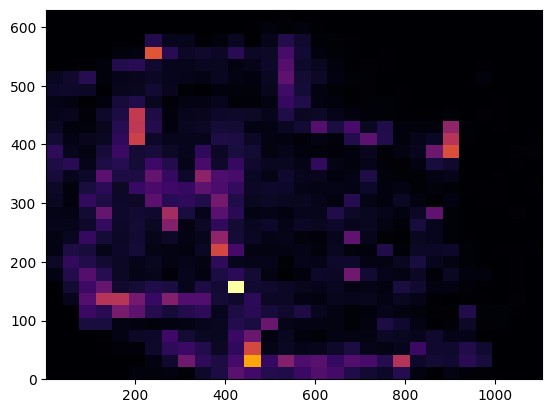

In [10]:
plt.hist2d(x, y, bins=30, cmap="inferno")

In [11]:
x = [value["bbox"][0]* 1280 / value["width"] for i, value in train2.iterrows()]
y = [value["bbox"][1]* 720 / value["height"] for i, value in train2.iterrows()]
w = [value["bbox"][2] / value["width"] for i, value in train2.iterrows()]
h = [value["bbox"][3] / value["height"] for i, value in train2.iterrows()]

In [12]:
newx = np.array(x)
newy = np.array(y)
newa = np.array(w)/np.array(h)

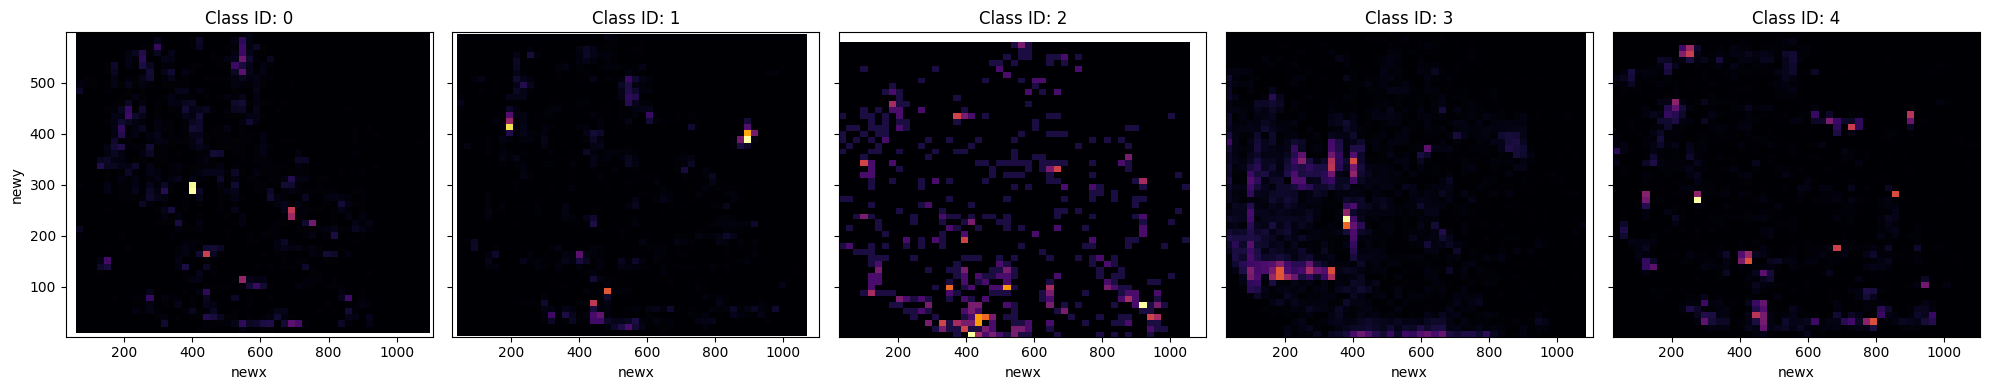

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)
for i in range(5):
    # Create the boolean mask for the current class_id
    mask = train2["class_id"] == i
    
    # Plot on the specific subplot axis
    axes[i].hist2d(
        newx[mask], 
        newy[mask], 
        bins=50, 
        cmap="inferno"
    )
    
    # Formatting
    axes[i].set_title(f"Class ID: {i}")
    axes[i].set_xlabel("newx")
    if i == 0:
        axes[i].set_ylabel("newy")

plt.tight_layout()

In [14]:
train2["class_id"].value_counts()

class_id
3    9928
4    6309
1    3435
0    3083
2     695
Name: count, dtype: int64

In [15]:
train2

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5, 368.0, 349.0, 435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5, 428.0, 233.0, 438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0, 137.5, 342.0, 198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0, 169.0, 370.0, 263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5, 314.8, 381.5, 386.6]",3
...,...,...,...,...,...,...
23445,train_pen2_tur_cam2_20250120_082753_0004,pen2_tur_cam2_20250120_082753.jpg,2688,1520,"[1507.5, 90.5, 554.0, 387.0]",4
23446,train_pen2_tur_cam2_20250120_082753_0005,pen2_tur_cam2_20250120_082753.jpg,2688,1520,"[1508.0, 828.5, 475.0, 319.0]",3
23447,train_pen2_tur_cam2_20250120_082753_0006,pen2_tur_cam2_20250120_082753.jpg,2688,1520,"[1896.6, 856.5, 325.0, 218.0]",4
23448,train_pen2_tur_cam2_20250120_082753_0007,pen2_tur_cam2_20250120_082753.jpg,2688,1520,"[2179.5, 318.0, 151.0, 397.0]",1


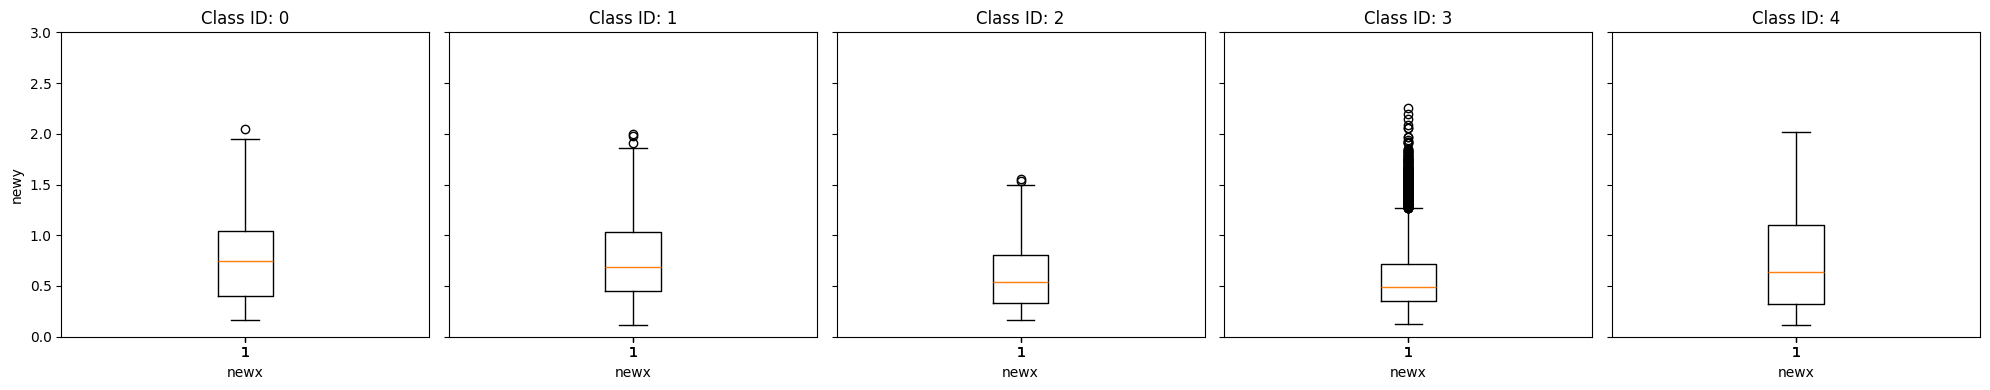

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)
for i in range(5):
    # Create the boolean mask for the current class_id
    mask = train2["class_id"] == i
    
    # Plot on the specific subplot axis
    axes[i].boxplot(
        newa[mask]
    )
    
    # Formatting
    axes[i].set_title(f"Class ID: {i}")
    axes[i].set_xlabel("newx")
    if i == 0:
        axes[i].set_ylabel("newy")
    axes[i].set_ylim([0, 3])

plt.tight_layout()

# Split based on images

In [59]:
from sklearn.model_selection import StratifiedGroupKFold

In [73]:
groups = train2.groupby("image_id")

In [74]:
sgkf = StratifiedGroupKFold(n_splits=5)
train_val_idx, test_idx = next(sgkf.split(train2, train2["class_id"], train2["image_id"]))

In [75]:
train_val_df = train2.iloc[train_val_idx].reset_index(drop=True)
test_df = train2.iloc[test_idx].reset_index(drop=True)

In [76]:
sgkf_val = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)
    
train_idx, val_idx = next(sgkf_val.split(train_val_df, train_val_df["class_id"], train_val_df["image_id"]))

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

In [77]:
train_df.to_csv("../data/split2_img/train.csv")
test_df.to_csv("../data/split2_img/test.csv")
val_df.to_csv("../data/split2_img/val.csv")

# Split train, test, validation data

In [17]:
train_df, temp_df = train_test_split(train2, test_size=0.3, random_state=42, stratify=train2["class_id"])

In [18]:
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["class_id"])

In [54]:
train_df.to_csv("../data/split2/train.csv")
test_df.to_csv("../data/split2/test.csv")
val_df.to_csv("../data/split2/val.csv")

# Baseline

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay

In [28]:
x = [value["bbox"][0]* 1280 / value["width"] for i, value in train_df.iterrows()]
y = [value["bbox"][1]* 720 / value["height"] for i, value in train_df.iterrows()]
w = [value["bbox"][2] / value["width"] for i, value in train_df.iterrows()]
h = [value["bbox"][3] / value["height"] for i, value in train_df.iterrows()]
a = np.array(w)/np.array(h)

In [29]:
train_df["x"] = x
train_df["y"] = y
train_df["w"] = w
train_df["h"] = h
train_df["a"] = a

In [30]:
target = train_df["class_id"]

In [34]:
data = train_df[["x", "y", "w", "h", "a"]]

In [36]:
tree = RandomForestClassifier()
tree.fit(data, target)

RandomForestClassifier()

In [37]:
x = [value["bbox"][0]* 1280 / value["width"] for i, value in test_df.iterrows()]
y = [value["bbox"][1]* 720 / value["height"] for i, value in test_df.iterrows()]
w = [value["bbox"][2] / value["width"] for i, value in test_df.iterrows()]
h = [value["bbox"][3] / value["height"] for i, value in test_df.iterrows()]
a = np.array(w)/np.array(h)

In [44]:
predict = pd.DataFrame()

In [45]:
predict["x"] = x
predict["y"] = y
predict["w"] = w
predict["h"] = h
predict["a"] = a

In [48]:
result = tree.predict(predict)

In [54]:
accuracy_score(test_df["class_id"], result)

0.8155201819215463

In [58]:
precision_score(test_df["class_id"], result, average="macro")

0.7850399202263121

In [ ]:
confusion_matrix(test_df["class_id"], result)

array([[ 337,   29,    3,   49,   44],
       [  20,  390,    0,   41,   65],
       [   6,    3,   34,   48,   13],
       [  31,   32,    5, 1363,   58],
       [  57,   63,    3,   79,  745]])

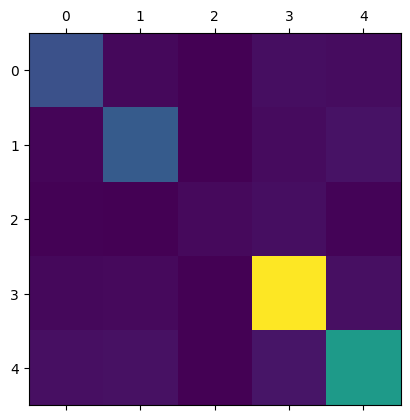

In [63]:
plt.matshow(confusion_matrix(test_df["class_id"], result))